# Detectability Diagnostics

This notebook aggregates artifact-level diagnostics from `python3 -m run_detectability_diagnostics`.

The diagnostics are not defenses by themselves. They measure how visible each saved trigger is among benign-labeled training rows:

- marginal trigger-value rarity
- joint trigger co-occurrence rarity
- trigger-SHAP concentration under the backdoored model
- kNN trigger-subspace density score
- AUROC / average precision / recall-at-budget using known poison labels for evaluation

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RESULTS_ROOT = PROJECT_ROOT / "results"
PLOTS_ROOT = RESULTS_ROOT / "plots"

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)

Project root: /Users/falcon/Machine Learning/Defense GMM-Maha
Results root: /Users/falcon/Machine Learning/Defense GMM-Maha/results


## How To Generate Diagnostics

Run the script once for each saved attack artifact. The artifact must contain `watermarked_X.npy`, `watermarked_y.npy`, `wm_config.npy`, and `defense_metadata.npz`. SHAP concentration also needs `backdoored_model_benign_shap.npy`.

In [12]:
example_command = """
python3 -m run_detectability_diagnostics \
  --artifact-dir results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__shap_largest_abs__min_population_new__problem_space_conservative \
  --overwrite

# Batch example for all EMBER2018 random artifacts:
python3 -m run_detectability_diagnostics \
  --artifact-glob "results/ember/20%/random-defense/attack_artifacts/*" \
  --overwrite
""".strip()
print(example_command)

python3 -m run_detectability_diagnostics   --artifact-dir results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__shap_largest_abs__min_population_new__problem_space_conservative   --overwrite

# Batch example for all EMBER2018 random artifacts:
python3 -m run_detectability_diagnostics   --artifact-glob "results/ember/20%/random-defense/attack_artifacts/*"   --overwrite


## Load Diagnostic Outputs

In [13]:
def dataset_label_from_parts(parts):
    if not parts:
        return None
    if parts[0] == "ember":
        return "EMBER2018"
    if parts[0] == "ember2024":
        return f"EMBER2024 {parts[1].upper()}" if len(parts) > 1 else "EMBER2024"
    return "/".join(parts)


def parse_experiment_name(name):
    parts = name.split("__")
    if len(parts) < 5:
        return {
            "baseline_tag": None,
            "model_family": None,
            "feature_selector": None,
            "value_selector": None,
            "target_features": None,
        }
    return {
        "baseline_tag": parts[0],
        "model_family": parts[1],
        "feature_selector": parts[2],
        "value_selector": parts[3],
        "target_features": "__".join(parts[4:]),
    }


def parse_artifact_dir(path):
    path = Path(path)
    out = {
        "artifact_dir": str(path),
        "artifact_name": path.name,
        "dataset_path": None,
        "dataset_label": None,
        "sampling_strategy": None,
    }
    out.update(parse_experiment_name(path.name))
    parts = list(path.resolve().parts)
    if "results" in parts and "attack_artifacts" in parts:
        r = parts.index("results")
        a = parts.index("attack_artifacts")
        before_attack = parts[r + 1 : a]
        sampling_idx = None
        for i, part in enumerate(before_attack):
            if part.endswith("-defense"):
                sampling_idx = i
                out["sampling_strategy"] = part[: -len("-defense")]
                break
        dataset_parts = before_attack[:sampling_idx] if sampling_idx is not None else before_attack
        out["dataset_path"] = "/".join(dataset_parts) if dataset_parts else None
        out["dataset_label"] = dataset_label_from_parts(dataset_parts)
    return out


def load_diagnostic_summaries():
    frames = []
    for path in sorted(RESULTS_ROOT.glob("**/detectability_diagnostics/*/detectability_summary.csv")):
        df = pd.read_csv(path)
        df["summary_path"] = str(path)
        frames.append(df)
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()


def load_score_metrics():
    frames = []
    for path in sorted(RESULTS_ROOT.glob("**/detectability_diagnostics/*/detectability_score_metrics.csv")):
        df = pd.read_csv(path)
        artifact_dir = path.parents[2]
        for key, value in parse_artifact_dir(artifact_dir).items():
            if key not in df.columns:
                df[key] = value
        df["score_metrics_path"] = str(path)
        frames.append(df)
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()


def discover_attack_artifacts():
    rows = []
    for path in sorted(RESULTS_ROOT.glob("**/attack_artifacts/*")):
        if not path.is_dir():
            continue
        required = ["watermarked_X.npy", "watermarked_y.npy", "wm_config.npy", "defense_metadata.npz"]
        if all((path / name).exists() for name in required):
            rows.append(parse_artifact_dir(path))
    return pd.DataFrame(rows)


diag_df = load_diagnostic_summaries()
score_df = load_score_metrics()
artifact_df = discover_attack_artifacts()

if not diag_df.empty and {"benign_rows_scored", "benign_rows_full"}.issubset(diag_df.columns):
    full_mask = diag_df["benign_rows_scored"].astype(float) >= diag_df["benign_rows_full"].astype(float)
    full_diag_df = diag_df[full_mask].copy()
else:
    full_diag_df = pd.DataFrame()

analysis_diag_df = full_diag_df.copy() if not full_diag_df.empty else diag_df.copy()
if not score_df.empty and not analysis_diag_df.empty and "artifact_dir" in score_df.columns:
    analysis_artifacts = set(analysis_diag_df["artifact_dir"].dropna().astype(str))
    analysis_score_df = score_df[score_df["artifact_dir"].astype(str).isin(analysis_artifacts)].copy()
else:
    analysis_score_df = score_df.copy()

print("Diagnostic summary rows:", len(diag_df))
print("Full-row diagnostic rows:", len(full_diag_df))
print("Analysis rows used for plots:", len(analysis_diag_df))
print("Score metric rows:", len(score_df))
print("Score metric rows used for plots:", len(analysis_score_df))
print("Discoverable artifact dirs:", len(artifact_df))
if diag_df.empty:
    print("No detectability_summary.csv files found yet. Run the command above for one or more artifacts.")
elif full_diag_df.empty:
    print("No full-row diagnostics found; plots will use available capped/smoke diagnostics for now.")

if not analysis_diag_df.empty:
    display(analysis_diag_df.head())


Diagnostic summary rows: 12
Full-row diagnostic rows: 11
Analysis rows used for plots: 11
Score metric rows: 322
Score metric rows used for plots: 322
Discoverable artifact dirs: 11


,artifact_name,dataset_path,dataset_label,sampling_strategy,baseline_tag,model_family,feature_selector,value_selector,target_features,artifact_dir,diagnostic_output_dir,total_train_rows,total_features,benign_rows_full,benign_rows_scored,clean_benign_rows_scored,poisoned_benign_rows_scored,watermark_feature_count,exact_atol,marginal_clean_frequency_min,marginal_clean_frequency_median,marginal_clean_frequency_mean,marginal_clean_frequency_max,marginal_neg_log10_frequency_sum,marginal_neg_log10_frequency_mean,clean_trigger_match_fraction_mean,poison_trigger_match_fraction_mean,poison_minus_clean_trigger_match_fraction_mean,shap_status,density_status,knn_neighbors,knn_reference_rows,joint_threshold_025p_required_features,joint_threshold_025p_clean_count,joint_threshold_025p_clean_frequency,joint_threshold_025p_poisoned_count,joint_threshold_025p_poisoned_frequency,joint_threshold_050p_required_features,joint_threshold_050p_clean_count,joint_threshold_050p_clean_frequency,joint_threshold_050p_poisoned_count,joint_threshold_050p_poisoned_frequency,joint_threshold_075p_required_features,joint_threshold_075p_clean_count,joint_threshold_075p_clean_frequency,joint_threshold_075p_poisoned_count,joint_threshold_075p_poisoned_frequency,joint_threshold_100p_required_features,joint_threshold_100p_clean_count,joint_threshold_100p_clean_frequency,joint_threshold_100p_poisoned_count,joint_threshold_100p_poisoned_frequency,joint_expected_independent_frequency,joint_all_lift_vs_independent,trigger_match_fraction_auroc,trigger_match_fraction_average_precision,trigger_match_fraction_valid_rows,trigger_match_fraction_recall_at_0p5p,trigger_match_fraction_recall_at_1p,trigger_match_fraction_recall_at_2p,trigger_match_fraction_recall_at_5p,trigger_match_fraction_recall_at_10p,trigger_match_fraction_recall_at_20p,trigger_match_fraction_recall_at_30p,trigger_rarity_score_auroc,trigger_rarity_score_average_precision,trigger_rarity_score_valid_rows,trigger_rarity_score_recall_at_0p5p,trigger_rarity_score_recall_at_1p,trigger_rarity_score_recall_at_2p,trigger_rarity_score_recall_at_5p,trigger_rarity_score_recall_at_10p,trigger_rarity_score_recall_at_20p,trigger_rarity_score_recall_at_30p,shap_trigger_abs_ratio_auroc,shap_trigger_abs_ratio_average_precision,shap_trigger_abs_ratio_valid_rows,shap_trigger_abs_ratio_recall_at_0p5p,shap_trigger_abs_ratio_recall_at_1p,shap_trigger_abs_ratio_recall_at_2p,shap_trigger_abs_ratio_recall_at_5p,shap_trigger_abs_ratio_recall_at_10p,shap_trigger_abs_ratio_recall_at_20p,shap_trigger_abs_ratio_recall_at_30p,shap_trigger_abs_ratio_clean_mean,shap_trigger_abs_ratio_poison_mean,shap_trigger_abs_ratio_poison_minus_clean_mean,shap_trigger_abs_ratio_clean_median,shap_trigger_abs_ratio_poison_median,shap_trigger_abs_ratio_poison_minus_clean_median,knn_trigger_mean_distance_auroc,knn_trigger_mean_distance_average_precision,knn_trigger_mean_distance_valid_rows,knn_trigger_mean_distance_recall_at_0p5p,knn_trigger_mean_distance_recall_at_1p,knn_trigger_mean_distance_recall_at_2p,knn_trigger_mean_distance_recall_at_5p,knn_trigger_mean_distance_recall_at_10p,knn_trigger_mean_distance_recall_at_20p,knn_trigger_mean_distance_recall_at_30p,knn_trigger_mean_distance_clean_mean,knn_trigger_mean_distance_poison_mean,knn_trigger_mean_distance_poison_minus_clean_mean,knn_trigger_mean_distance_clean_median,knn_trigger_mean_distance_poison_median,knn_trigger_mean_distance_poison_minus_clean_median,summary_path
0,ember__lightgbm__combined_shap__combined_shap_...,ember/20%,EMBER2018,random,ember,lightgbm,combined_shap,combined_shap,problem_space_conservative,/Users/falcon/Machine Learning/Defense GMM-Mah...,/Users/falcon/Machine Learning/Defense GMM-Mah...,120000,2381,82709,82709,82109,600,17,0.000001,0.000085,0.733842,0.540507,0.990208,11.495070,0.676181,0.540507,1.0,0.459493,computed,computed,10,10000,5,81523,0.992863,600,1.0,9,53945,0.656993,600,1.0,13,4403,0.053624,600,1.0,17,2,0.000024,600,1.0,3.198379e-12,7.615691e+06,0.999988,0.996678,8270

## Missing Diagnostics

This table shows saved attack artifacts that have the required files but do not yet have a `detectability_summary.csv`.

In [14]:
if artifact_df.empty:
    missing_df = pd.DataFrame()
    print("No saved attack artifacts with the required files were found.")
else:
    done = set()
    if not diag_df.empty and "artifact_dir" in diag_df.columns:
        done = {str(Path(value).resolve()) for value in diag_df["artifact_dir"].dropna().astype(str)}
    missing_mask = ~artifact_df["artifact_dir"].map(lambda value: str(Path(value).resolve()) in done)
    missing_df = artifact_df[missing_mask].copy()
    print("Missing diagnostics:", len(missing_df))
    display(missing_df[["dataset_label", "sampling_strategy", "feature_selector", "value_selector", "target_features", "artifact_dir"]].head(50))

Missing diagnostics: 0


,dataset_label,sampling_strategy,feature_selector,value_selector,target_features,artifact_dir


## Load Attack Summary Metrics

When matching `summary_df.csv` files exist, the notebook joins detectability diagnostics with attack effectiveness (`evasions_success_percent`).

In [15]:
def parse_attack_summary_path(path):
    path = Path(path)
    parts = list(path.resolve().parts)
    out = {
        "summary_df_path": str(path),
        "dataset_path": None,
        "dataset_label": None,
        "sampling_strategy": None,
        **parse_experiment_name(path.parent.name),
    }
    if "results" in parts:
        r = parts.index("results")
        rel = parts[r + 1 :]
        if len(rel) >= 4:
            out["sampling_strategy"] = rel[-3]
            dataset_parts = rel[:-3]
            out["dataset_path"] = "/".join(dataset_parts) if dataset_parts else None
            out["dataset_label"] = dataset_label_from_parts(dataset_parts)
    return out


def load_attack_summaries():
    frames = []
    for path in sorted(RESULTS_ROOT.glob("**/*__summary_df.csv")):
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            print("Could not read", path, exc)
            continue
        parsed = parse_attack_summary_path(path)
        for key, value in parsed.items():
            df[key] = value
        frames.append(df)
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

attack_df = load_attack_summaries()
print("Attack summary rows:", len(attack_df))

join_cols = ["dataset_label", "sampling_strategy", "feature_selector", "value_selector", "target_features"]
if not analysis_diag_df.empty and not attack_df.empty:
    merged_df = analysis_diag_df.merge(
        attack_df,
        on=join_cols,
        how="left",
        suffixes=("", "_attack"),
    )
else:
    merged_df = analysis_diag_df.copy()

if not merged_df.empty:
    display_cols = [
        "dataset_label", "sampling_strategy", "feature_selector", "value_selector", "target_features",
        "evasions_success_percent", "marginal_neg_log10_frequency_sum",
        "joint_threshold_100p_clean_frequency", "trigger_rarity_score_auroc",
        "shap_trigger_abs_ratio_auroc", "knn_trigger_mean_distance_auroc",
    ]
    existing = [col for col in display_cols if col in merged_df.columns]
    display(merged_df[existing].head(30))

Attack summary rows: 253


,dataset_label,sampling_strategy,feature_selector,value_selector,target_features,evasions_success_percent,marginal_neg_log10_frequency_sum,joint_threshold_100p_clean_frequency,trigger_rarity_score_auroc,shap_trigger_abs_ratio_auroc,knn_trigger_mean_distance_auroc
0,EMBER2018,random,combined_shap,combined_shap,problem_space_conservative,20.359048,11.495070,0.000024,0.999988,0.254376,0.298238
1,EMBER2018,random,shap_largest_abs,argmin_Nv_sum_abs_shap,problem_space_conservative,81.932527,113.206872,0.000000,1.000000,0.994529,1.000000
2,EMBER2018,random,shap_largest_abs,benign_prototype,problem_space_conservative,22.214915,11.568253,0.000012,0.999994,0.142268,0.448276
3,EMBER2018,random,shap_largest_abs,corr_count_abs_shap,problem_space_conservative,33.231942,20.862129,0.000012,0.999994,0.681175,0.995317
4,EMBER2018,random,shap_largest_abs,frequency_bounded,problem_space_conservative,77.442890,65.824633,0.000000,1.000000,0.975873,0.997662
5,EMBER2018,random,shap_largest_abs,frequency_bounded_signed_shap,problem_space_conservative,82.677546,39.011297,0.000000,1.000000,0.981692,0.997418
6,EMBER2018,random,shap_largest_abs,low_shap_signed,problem_space_conservative,87.715927,58.223106,0.000000,1.000000,0.993027,0.999963
7,EMBER2018,random,shap_largest_abs,min_population_new,problem_space_conservative,94.597844,104.500441,0.000000,1.000000,0.999611,0.999939
8,EMBER2018,random,shap_largest_abs,quantile_05,problem_space_conservative,72.393205,17.761158,0.000000,1.000000,0.792832,0.890889
9,EMBER2018,random,shap_largest_abs,quantile_50,problem_space_conservative,23.831348,8.278810,0.000000,1.000000,0.151920,0.467927


## Summary Heatmaps

Higher AUROC means the score separates poisoned benign rows from clean benign rows more strongly. For `joint_all_clean_frequency`, lower means the exact trigger combination is rarer among clean benign rows.

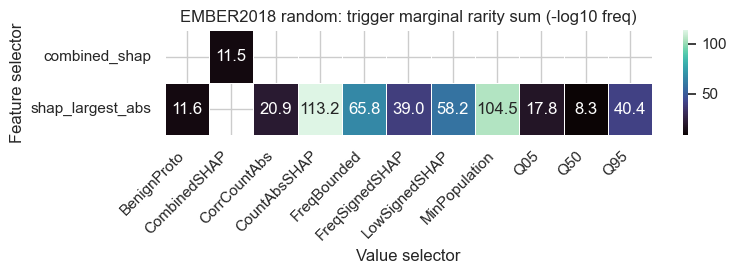

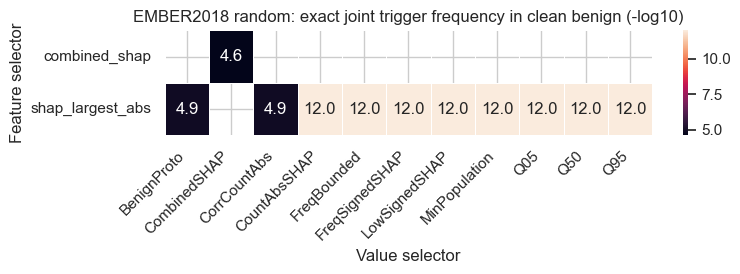

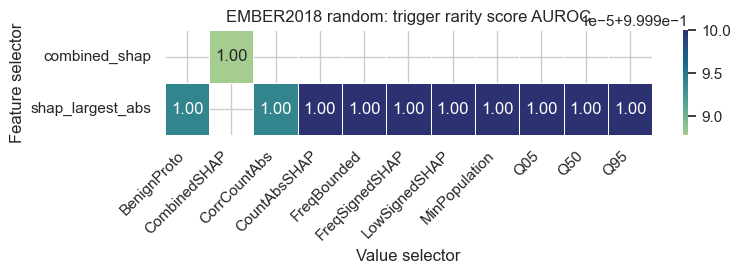

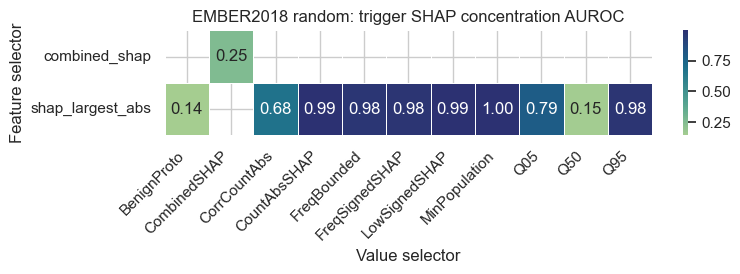

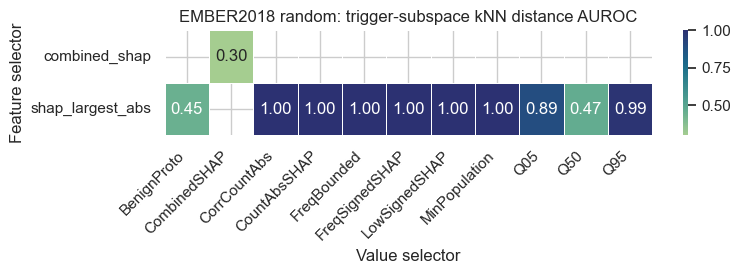

In [16]:
VALUE_ORDER = [
    "combined_shap",
    "argmin_Nv_sum_abs_shap",
    "min_population_new",
    "low_shap_signed",
    "frequency_bounded",
    "frequency_bounded_signed_shap",
    "quantile_05",
    "quantile_50",
    "quantile_95",
    "benign_prototype",
    "corr_count_abs_shap",
]

VALUE_LABELS = {
    "combined_shap": "CombinedSHAP",
    "argmin_Nv_sum_abs_shap": "CountAbsSHAP",
    "min_population_new": "MinPopulation",
    "low_shap_signed": "LowSignedSHAP",
    "frequency_bounded": "FreqBounded",
    "frequency_bounded_signed_shap": "FreqSignedSHAP",
    "quantile_05": "Q05",
    "quantile_50": "Q50",
    "quantile_95": "Q95",
    "benign_prototype": "BenignProto",
    "corr_count_abs_shap": "CorrCountAbs",
}


def add_selector_labels(df):
    out = df.copy()
    if "value_selector" in out.columns:
        out["value_selector"] = pd.Categorical(out["value_selector"], categories=VALUE_ORDER, ordered=True)
        out["selector_label"] = out["value_selector"].astype(str).map(VALUE_LABELS).fillna(out["value_selector"].astype(str))
    return out


def heatmap_metric(df, metric, title, *, dataset_label="EMBER2018", sampling_strategy="random", cmap="viridis", fmt=".2f", transform=None):
    if df.empty:
        print("No data for", title)
        return
    focus = df.copy()
    if dataset_label is not None and "dataset_label" in focus.columns:
        focus = focus[focus["dataset_label"] == dataset_label]
    if sampling_strategy is not None and "sampling_strategy" in focus.columns:
        focus = focus[focus["sampling_strategy"] == sampling_strategy]
    if metric not in focus.columns or focus.empty:
        print("No rows for", title)
        return
    focus = add_selector_labels(focus)
    value_col = metric
    if transform is not None:
        value_col = f"{metric}_plot"
        focus[value_col] = transform(focus[metric])
    pivot = focus.pivot_table(
        index="feature_selector",
        columns="selector_label",
        values=value_col,
        aggfunc="mean",
        observed=False,
    )
    if pivot.empty:
        print("Empty pivot for", title)
        return
    plt.figure(figsize=(max(8, 0.7 * pivot.shape[1]), max(2.8, 0.55 * pivot.shape[0] + 1.8)))
    ax = sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, linewidths=0.5, linecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Value selector")
    ax.set_ylabel("Feature selector")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


if not merged_df.empty:
    heatmap_metric(
        merged_df,
        "marginal_neg_log10_frequency_sum",
        "EMBER2018 random: trigger marginal rarity sum (-log10 freq)",
        fmt=".1f",
        cmap="mako",
    )
    heatmap_metric(
        merged_df,
        "joint_threshold_100p_clean_frequency",
        "EMBER2018 random: exact joint trigger frequency in clean benign (-log10)",
        fmt=".1f",
        cmap="rocket",
        transform=lambda s: -np.log10(s.astype(float).fillna(0) + 1e-12),
    )
    heatmap_metric(
        merged_df,
        "trigger_rarity_score_auroc",
        "EMBER2018 random: trigger rarity score AUROC",
        fmt=".2f",
        cmap="crest",
    )
    heatmap_metric(
        merged_df,
        "shap_trigger_abs_ratio_auroc",
        "EMBER2018 random: trigger SHAP concentration AUROC",
        fmt=".2f",
        cmap="crest",
    )
    heatmap_metric(
        merged_df,
        "knn_trigger_mean_distance_auroc",
        "EMBER2018 random: trigger-subspace kNN distance AUROC",
        fmt=".2f",
        cmap="crest",
    )

## Effectiveness vs Detectability

These plots are useful for the paper story: a value selector can have high attack effectiveness while also being more or less detectable by different non-defense signals.

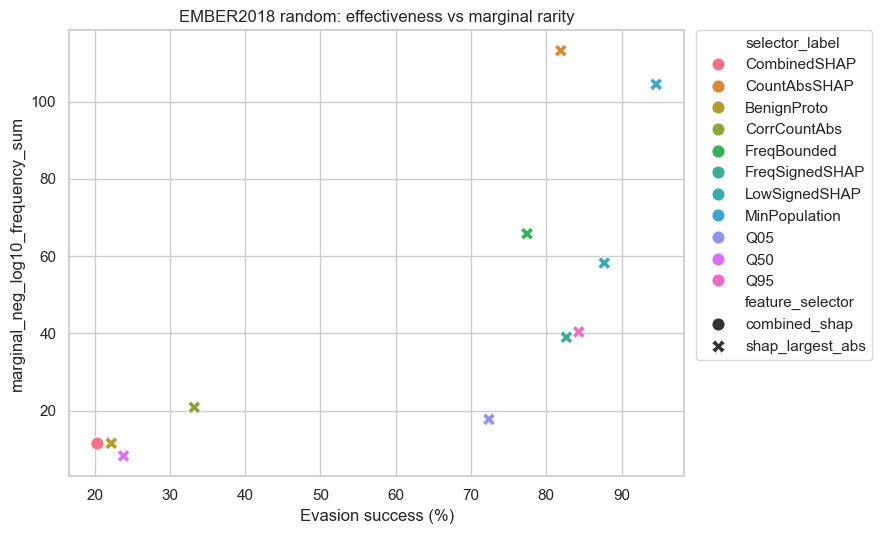

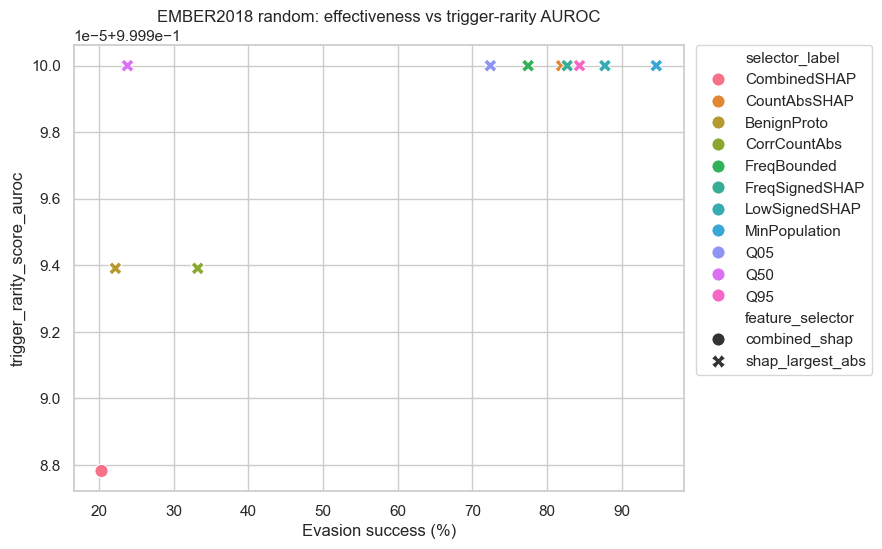

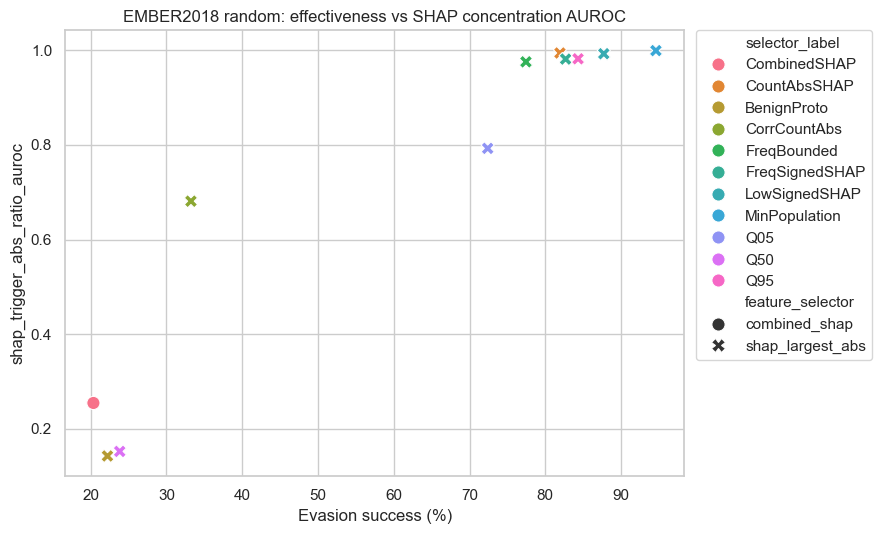

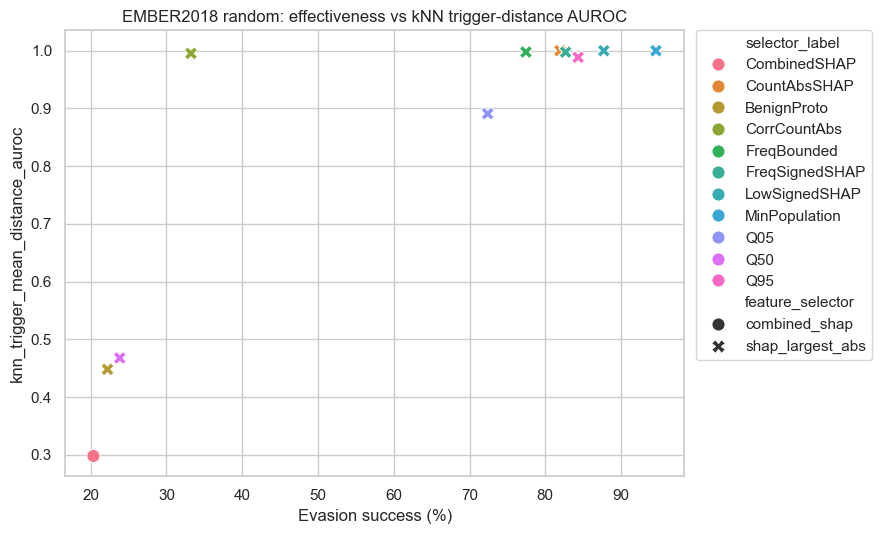

In [17]:
def scatter_effectiveness_vs_metric(df, metric, title, *, dataset_label="EMBER2018", sampling_strategy="random"):
    if df.empty or "evasions_success_percent" not in df.columns or metric not in df.columns:
        print("Missing columns for", title)
        return
    focus = df[
        (df["dataset_label"] == dataset_label)
        & (df["sampling_strategy"] == sampling_strategy)
    ].copy()
    focus = focus.dropna(subset=["evasions_success_percent", metric])
    if focus.empty:
        print("No rows for", title)
        return
    focus = add_selector_labels(focus)
    plt.figure(figsize=(9, 5.5))
    ax = sns.scatterplot(
        data=focus,
        x="evasions_success_percent",
        y=metric,
        hue="selector_label",
        style="feature_selector",
        s=90,
    )
    ax.set_title(title)
    ax.set_xlabel("Evasion success (%)")
    ax.set_ylabel(metric)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

if not merged_df.empty:
    scatter_effectiveness_vs_metric(
        merged_df,
        "marginal_neg_log10_frequency_sum",
        "EMBER2018 random: effectiveness vs marginal rarity",
    )
    scatter_effectiveness_vs_metric(
        merged_df,
        "trigger_rarity_score_auroc",
        "EMBER2018 random: effectiveness vs trigger-rarity AUROC",
    )
    scatter_effectiveness_vs_metric(
        merged_df,
        "shap_trigger_abs_ratio_auroc",
        "EMBER2018 random: effectiveness vs SHAP concentration AUROC",
    )
    scatter_effectiveness_vs_metric(
        merged_df,
        "knn_trigger_mean_distance_auroc",
        "EMBER2018 random: effectiveness vs kNN trigger-distance AUROC",
    )

## Recall-at-Budget Curves

This uses known poison labels only to evaluate score quality. It answers: if we flagged the top X% most suspicious benign-labeled rows by a diagnostic score, how many poisoned rows would be included?

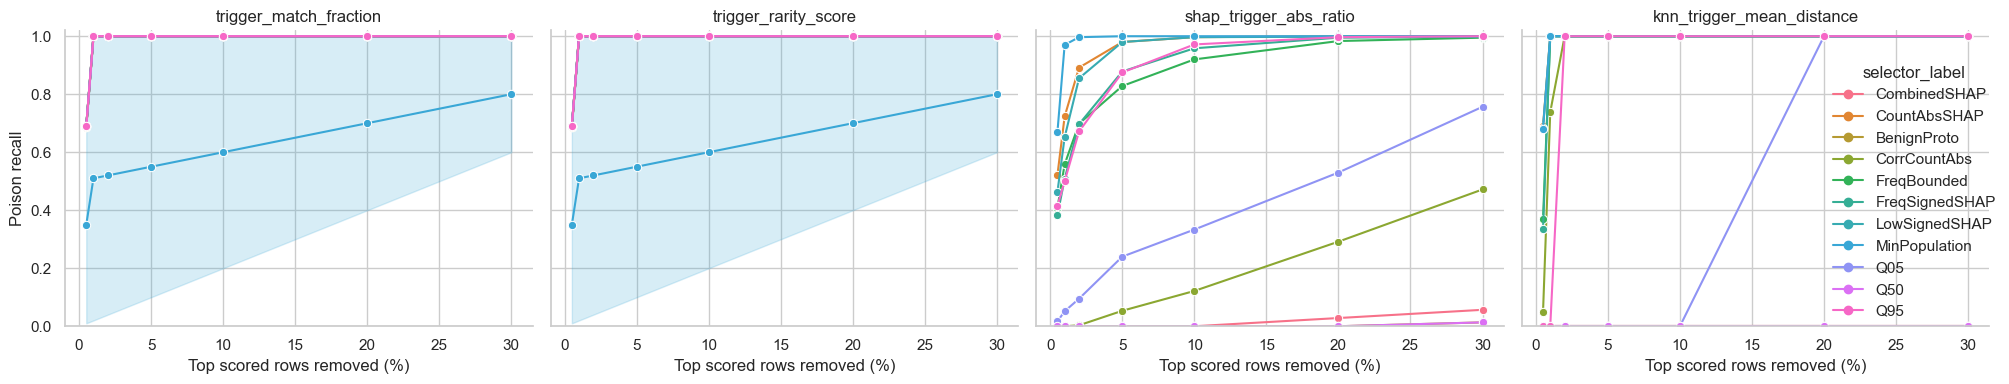

In [18]:
if analysis_score_df.empty:
    print("No detectability_score_metrics.csv files found for the current analysis rows.")
else:
    focus_scores = analysis_score_df[
        (score_df["dataset_label"] == "EMBER2018")
        & (score_df["sampling_strategy"] == "random")
    ].copy()
    if focus_scores.empty:
        print("No EMBER2018 random score metrics found.")
    else:
        focus_scores = add_selector_labels(focus_scores)
        g = sns.relplot(
            data=focus_scores,
            x="top_percent",
            y="poison_recall",
            hue="selector_label",
            col="score_name",
            kind="line",
            marker="o",
            facet_kws={"sharey": True, "sharex": True},
            height=4,
            aspect=1.15,
        )
        g.set_axis_labels("Top scored rows removed (%)", "Poison recall")
        g.set_titles("{col_name}")
        for ax in g.axes.flat:
            ax.set_ylim(0, 1.02)
        plt.tight_layout()
        plt.show()

## Inspect One Artifact Deeply

Pick one diagnostic run and inspect its trigger values plus row-score distributions.

Focus diagnostic dir: /Users/falcon/Machine Learning/Defense GMM-Maha/results/ember/20%/random-defense/attack_artifacts/ember__lightgbm__shap_largest_abs__argmin_Nv_sum_abs_shap__problem_space_conservative/detectability_diagnostics/default_full


,watermark_rank,feature_id,feature_name,watermark_value,clean_exact_count,clean_exact_frequency,neg_log10_clean_frequency,poisoned_exact_frequency,clean_percentile_leq_value,trigger_z_from_clean
12,13,613,urls_count,1.640000e+02,0,0.000000,12.000000,1.0,0.986457,1.684303
11,12,681,major_operating_system_version,6.553500e+04,0,0.000000,12.000000,1.0,1.000000,37119.953244
4,5,689,num_zero_size_sections,1.700000e+01,0,0.000000,12.000000,1.0,0.999976,21.553971
10,11,677,major_image_version,8.000000e+01,0,0.000000,12.000000,1.0,0.996748,0.119679
15,16,626,timestamp,1.507300e+09,0,0.000000,12.000000,1.0,0.846034,0.452848
16,17,691,num_read_and_execute_sections,3.100000e+01,1,0.000012,4.914391,1.0,0.999963,29.542033
1,2,614,registry_count,4.000000e+01,1,0.000012,4.914391,1.0,0.999415,13.470193
6,7,612,paths_count,9.200000e+01,1,0.000012,4.914391,1.0,0.996249,0.097850
0,1,690,num_unnamed_sections,1.300000e+01,2,0.000024,4.613361,1.0,1.000000,39.390058
5,6,680,minor_linker_version,4.000000e+01,3,0.000037,4.437270,1.0,0.985544,3.493059


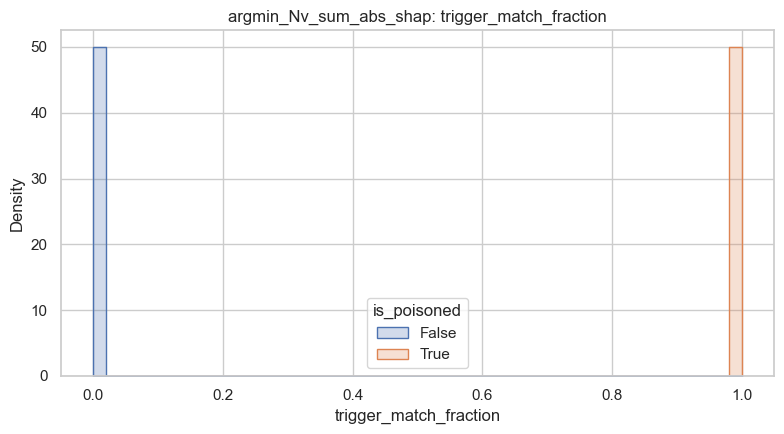

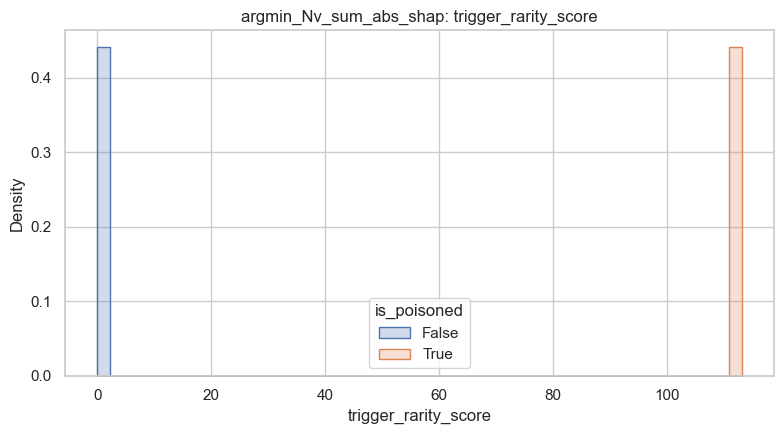

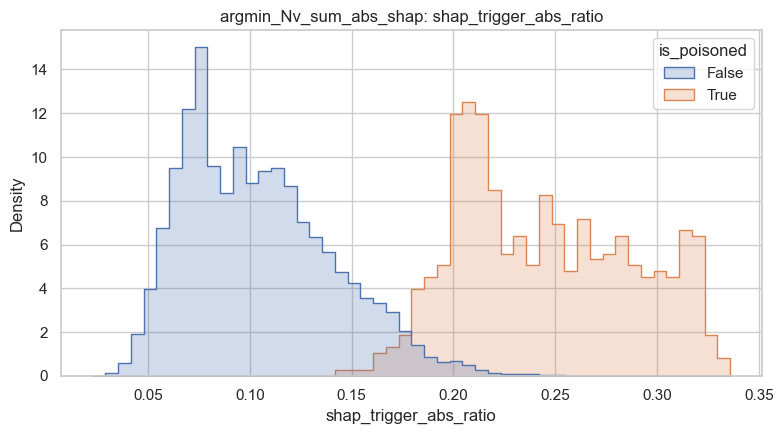

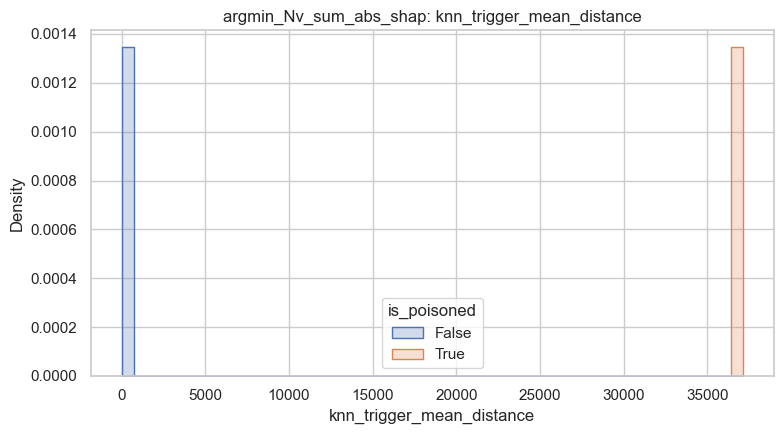

In [21]:
if analysis_diag_df.empty:
    print("No diagnostics available yet.")
else:
    FOCUS_INDEX = 1
    focus = analysis_diag_df.iloc[FOCUS_INDEX]
    diagnostic_dir = Path(focus["diagnostic_output_dir"])
    print("Focus diagnostic dir:", diagnostic_dir)

    marginal_path = diagnostic_dir / "trigger_marginal_rarity.csv"
    row_scores_path = diagnostic_dir / "detectability_row_scores.csv"

    if marginal_path.exists():
        marginal = pd.read_csv(marginal_path)
        display(
            marginal.sort_values("clean_exact_frequency")[[
                "watermark_rank", "feature_id", "feature_name", "watermark_value",
                "clean_exact_count", "clean_exact_frequency", "neg_log10_clean_frequency",
                "poisoned_exact_frequency", "clean_percentile_leq_value", "trigger_z_from_clean",
            ]]
        )

    if row_scores_path.exists():
        rows = pd.read_csv(row_scores_path)
        plot_cols = [
            "trigger_match_fraction",
            "trigger_rarity_score",
            "shap_trigger_abs_ratio",
            "knn_trigger_mean_distance",
        ]
        for col in plot_cols:
            if col not in rows.columns:
                continue
            plt.figure(figsize=(8, 4.5))
            sns.histplot(
                data=rows,
                x=col,
                hue="is_poisoned",
                bins=50,
                stat="density",
                common_norm=False,
                element="step",
            )
            plt.title(f"{focus.get('value_selector', 'artifact')}: {col}")
            plt.tight_layout()
            plt.show()
    else:
        print("No row-score file saved for this diagnostic.")

## Save Aggregated Tables

In [22]:
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)
if not diag_df.empty:
    diag_out = PLOTS_ROOT / "detectability_diagnostics_summary.csv"
    diag_df.to_csv(diag_out, index=False)
    print("Saved:", diag_out)
if not analysis_diag_df.empty:
    analysis_out = PLOTS_ROOT / "detectability_diagnostics_analysis_rows.csv"
    analysis_diag_df.to_csv(analysis_out, index=False)
    print("Saved:", analysis_out)
if not score_df.empty:
    score_out = PLOTS_ROOT / "detectability_score_metrics.csv"
    score_df.to_csv(score_out, index=False)
    print("Saved:", score_out)
if not merged_df.empty:
    merged_out = PLOTS_ROOT / "detectability_with_attack_metrics.csv"
    merged_df.to_csv(merged_out, index=False)
    print("Saved:", merged_out)

Saved: /Users/falcon/Machine Learning/Defense GMM-Maha/results/plots/detectability_diagnostics_summary.csv
Saved: /Users/falcon/Machine Learning/Defense GMM-Maha/results/plots/detectability_diagnostics_analysis_rows.csv
Saved: /Users/falcon/Machine Learning/Defense GMM-Maha/results/plots/detectability_score_metrics.csv
Saved: /Users/falcon/Machine Learning/Defense GMM-Maha/results/plots/detectability_with_attack_metrics.csv
